In [26]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

model2 = joblib.load(
    "../models/lightgbm_model2.pkl"
)

X_test2 = pd.read_csv(
    "../datasets/processed/X_test_model2.csv"
)

y_test2 = pd.read_csv(
    "../datasets/processed/y_test_model2.csv"
).squeeze()

print("Model loaded successfully!")
print("X_test shape:", X_test2.shape)
print("Number of features:", X_test2.shape[1])

Model loaded successfully!
X_test shape: (101435, 27)
Number of features: 27


In [27]:
print(X_test2.columns.tolist())

['URL_Length', 'No_of_Dots', 'No_of_Hyphens', 'No_of_Digits', 'Has_HTTPS', 'No_of_Slashes', 'No_of_Underscores', 'No_of_QuestionMarks', 'No_of_EqualSigns', 'No_of_At', 'Has_IP', 'Domain_Length', 'Subdomain_Count', 'Path_Length', 'Query_Length', 'Fragment_Length', 'Path_Depth', 'Digit_Ratio', 'Special_Character_Count', 'Suspicious_Keyword_Count', 'Shortening_Service', 'Punycode_Indicator', 'Port_Presence', 'Double_Slash_Redirect', 'WWW_Indicator', 'IP_Address_Indicator', 'URL_Entropy']


In [28]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

print("XAI libraries loaded successfully!")

XAI libraries loaded successfully!


In [29]:
model = joblib.load("lightgbm_model.pkl")

print("LightGBM model loaded successfully!")
print(model)

FileNotFoundError: [Errno 2] No such file or directory: 'lightgbm_model.pkl'

In [ ]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nFeatures:")
print(X_test.columns.tolist())

Training data: (405756, 11)
Testing data: (101440, 11)

Features:
['URL_Length', 'No_of_Dots', 'No_of_Hyphens', 'No_of_Digits', 'Has_HTTPS', 'No_of_Slashes', 'No_of_Underscores', 'No_of_QuestionMarks', 'No_of_EqualSigns', 'No_of_At', 'Has_IP']


In [ ]:
predictions = model.predict(X_test)

probabilities = model.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(predictions[:10])

print("\nFirst 10 phishing probabilities:")
print(probabilities[:10])

c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.1

First 10 predictions:
[0 0 1 1 0 0 0 0 1 0]

First 10 phishing probabilities:
[0.13902016 0.15525695 0.98654635 0.91024768 0.18475157 0.18694517
 0.00382081 0.25759434 0.62057912 0.0214811 ]


In [ ]:
explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer created successfully!")

SHAP TreeExplainer created successfully!


In [ ]:
X_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

shap_values = explainer(X_sample)

print("SHAP values calculated!")
print(shap_values.values.shape)

SHAP values calculated!
(1000, 11)


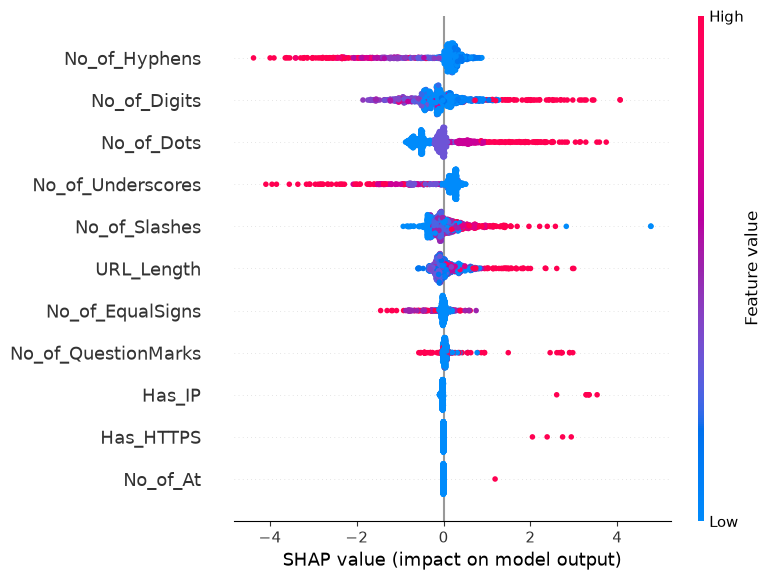

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [ ]:
# Find a test sample predicted as phishing
phishing_indices = np.where(model.predict(X_test) == 1)[0]

sample_index = phishing_indices[0]

sample = X_test.iloc[[sample_index]]

prediction = model.predict(sample)[0]
probability = model.predict_proba(sample)[0, 1]

print("Sample index:", sample_index)
print("Prediction:", "PHISHING" if prediction == 1 else "LEGITIMATE")
print(f"Phishing probability: {probability * 100:.2f}%")

print("\nFeature values:")
display(sample)

Sample index: 2
Prediction: PHISHING
Phishing probability: 98.65%

Feature values:


,URL_Length,No_of_Dots,No_of_Hyphens,No_of_Digits,Has_HTTPS,No_of_Slashes,No_of_Underscores,No_of_QuestionMarks,No_of_EqualSigns,No_of_At,Has_IP
2,142,14,0,39,0,2,0,0,0,0,0


In [ ]:
sample_shap = explainer(sample)

print("SHAP explanation generated!")

SHAP explanation generated!


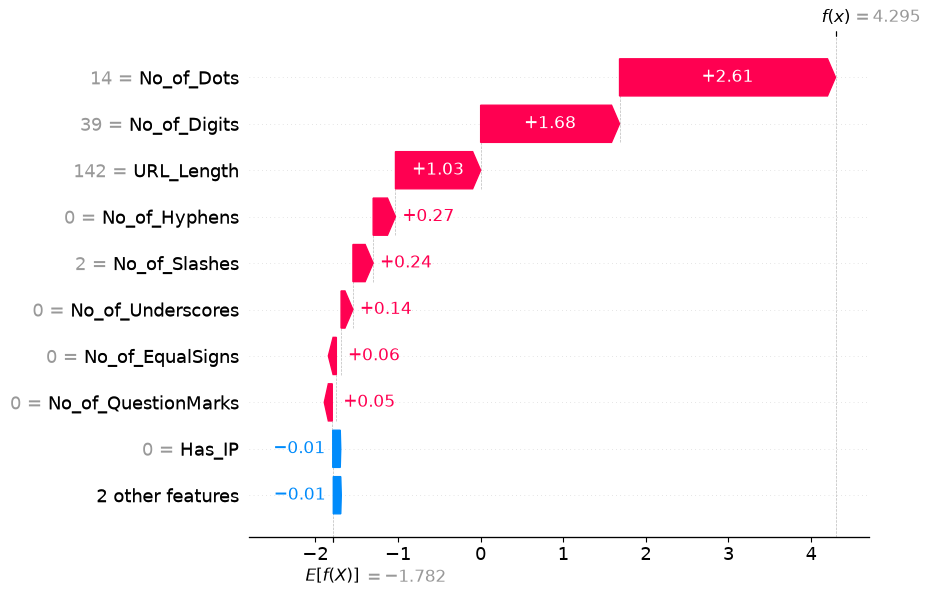

In [ ]:
shap.plots.waterfall(sample_shap[0])

In [ ]:
shap_data = pd.DataFrame({
    "Feature": sample.columns,
    "Value": sample.iloc[0].values,
    "SHAP_Value": sample_shap.values[0]
})

shap_data["Impact"] = shap_data["SHAP_Value"].abs()

shap_data = shap_data.sort_values(
    "Impact",
    ascending=False
)

shap_data

,Feature,Value,SHAP_Value,Impact
1,No_of_Dots,14,2.613524,2.613524
3,No_of_Digits,39,1.680704,1.680704
0,URL_Length,142,1.030741,1.030741
2,No_of_Hyphens,0,0.270014,0.270014
5,No_of_Slashes,2,0.244615,0.244615
6,No_of_Underscores,0,0.143449,0.143449
8,No_of_EqualSigns,0,0.057329,0.057329
7,No_of_QuestionMarks,0,0.049447,0.049447
10,Has_IP,0,-0.005988,0.005988
4,Has_HTTPS,0,-0.004052,0.004052


In [ ]:
predictions2 = model2.predict(X_test2)

probabilities2 = model2.predict_proba(X_test2)[:, 1]

print("First 10 predictions:")
print(predictions2[:10])

print("\nFirst 10 phishing probabilities:")
print(probabilities2[:10])

c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.1

First 10 predictions:
[0 1 0 0 1 0 0 0 1 0]

First 10 phishing probabilities:
[0.0810776  0.99885265 0.00862557 0.0497788  0.94149484 0.01563713
 0.05182911 0.08331932 0.98132341 0.09274933]


In [ ]:
explainer2 = shap.TreeExplainer(model2)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [ ]:
X_sample2 = X_test2.sample(
    n=min(1000, len(X_test2)),
    random_state=42
)

shap_values2 = explainer2(X_sample2)

print("SHAP values calculated!")
print("Shape:", shap_values2.values.shape)

SHAP values calculated!
Shape: (1000, 27)


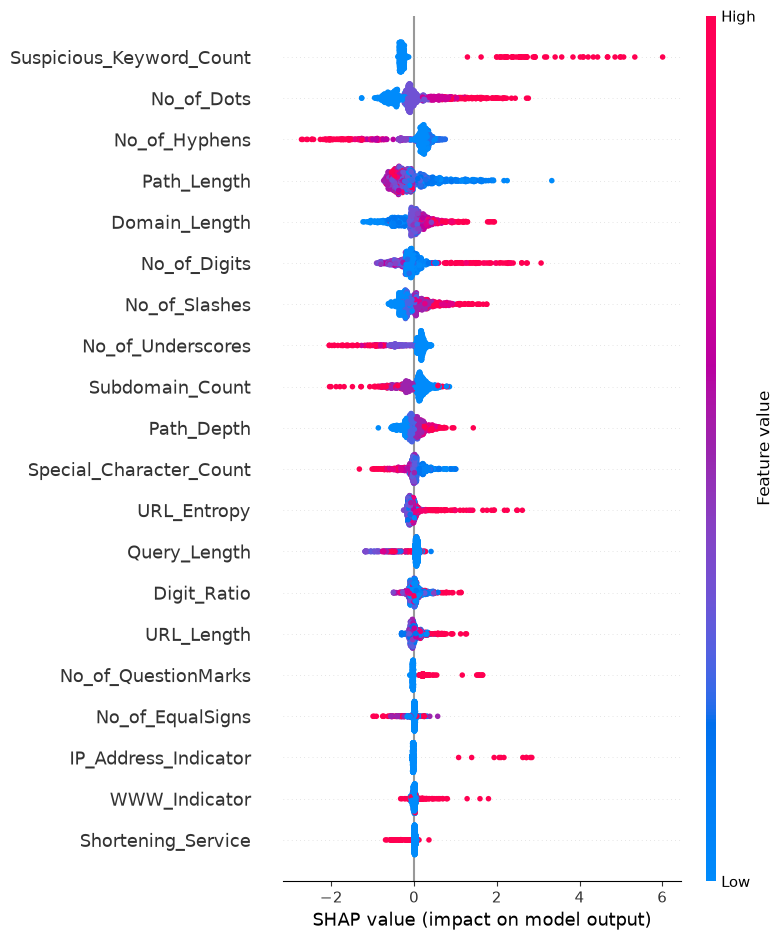

In [ ]:
shap.summary_plot(
    shap_values2,
    X_sample2
)

In [ ]:
sample_index = 0

sample = X_test2.iloc[[sample_index]]

print(sample)

   URL_Length  No_of_Dots  No_of_Hyphens  No_of_Digits  Has_HTTPS  \
0          35           2              0             0          0   

   No_of_Slashes  No_of_Underscores  No_of_QuestionMarks  No_of_EqualSigns  \
0              1                  0                    0                 0   

   No_of_At  ...  Digit_Ratio  Special_Character_Count  \
0         0  ...          0.0                      3.0   

   Suspicious_Keyword_Count  Shortening_Service  Punycode_Indicator  \
0                       0.0                 0.0                 0.0   

   Port_Presence  Double_Slash_Redirect  WWW_Indicator  IP_Address_Indicator  \
0            0.0                    0.0            0.0                   0.0   

   URL_Entropy  
0     3.671582  

[1 rows x 27 columns]


In [ ]:
prediction = model2.predict(sample)[0]

probability = model2.predict_proba(sample)[0]

print("Prediction:", prediction)
print("Probabilities:", probability)

Prediction: 0
Probabilities: [0.9189224 0.0810776]


In [ ]:
sample_shap = explainer2(sample)

print(sample_shap.values)

[[-1.70943411e-02 -1.50430271e-01  1.42522713e-01 -2.04799955e-01
  -3.28604148e-03 -3.19534184e-01  1.95369345e-01 -2.36737707e-02
   1.49981703e-02 -4.51230089e-03 -8.87248483e-03  3.77042419e-01
  -1.67547713e-01  8.39277304e-02  9.43783632e-02 -5.37690423e-05
  -2.49323666e-01 -1.21573367e-01  3.06469829e-01 -2.59333592e-01
   3.56183331e-02 -4.49817072e-04 -5.41631674e-03 -4.62714748e-03
  -7.30672171e-02 -2.03704590e-02 -9.44970469e-02]]


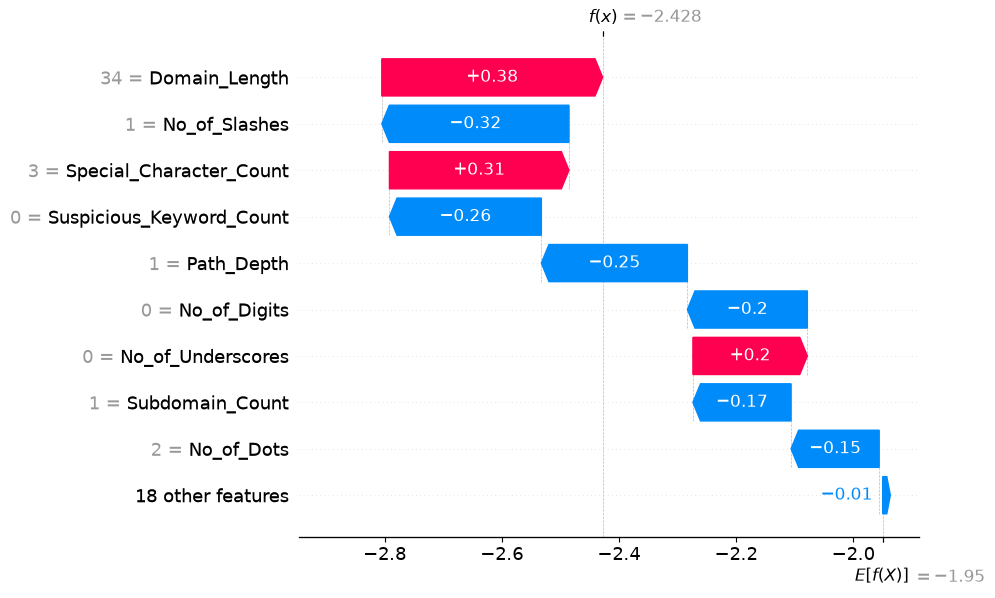

In [ ]:
shap.plots.waterfall(sample_shap[0])

In [ ]:
import pandas as pd
import numpy as np

values = sample_shap.values[0]

feature_names = sample.columns.tolist()

importance = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": values,
    "Absolute_SHAP": np.abs(values)
})

importance = importance.sort_values(
    "Absolute_SHAP",
    ascending=False
)

print(importance.head(5))


                     Feature  SHAP_Value  Absolute_SHAP
11             Domain_Length    0.377042       0.377042
5              No_of_Slashes   -0.319534       0.319534
18   Special_Character_Count    0.306470       0.306470
19  Suspicious_Keyword_Count   -0.259334       0.259334
16                Path_Depth   -0.249324       0.249324


In [ ]:
prediction = model2.predict(sample)[0]
probabilities = model2.predict_proba(sample)[0]

print("Model classes:", model2.classes_)
print("Prediction:", prediction)
print("Probabilities:", probabilities)

Model classes: [0 1]
Prediction: 0
Probabilities: [0.9189224 0.0810776]


In [ ]:
top_features = importance.head(5)

print("Top 5 contributing features:")
print(top_features[["Feature", "SHAP_Value"]])

Top 5 contributing features:
                     Feature  SHAP_Value
11             Domain_Length    0.377042
5              No_of_Slashes   -0.319534
18   Special_Character_Count    0.306470
19  Suspicious_Keyword_Count   -0.259334
16                Path_Depth   -0.249324


In [ ]:
def generate_explanation(importance, prediction_label):
    explanations = []

    top_features = importance.head(5)

    for _, row in top_features.iterrows():

        feature = row["Feature"]
        value = row["SHAP_Value"]

        if value > 0:
            direction = "increased"
        else:
            direction = "decreased"

        explanations.append(
            f"{feature} {direction} the model's prediction "
            f"(SHAP value: {value:.2f})."
        )

    explanation = (
        f"The URL was classified as {prediction_label}. "
        "The main factors influencing this prediction were: "
        + " ".join(explanations)
    )

    return explanation

In [ ]:
label_map = {
    0: "Legitimate",
    1: "Phishing"
}

prediction_label = label_map[prediction]

print("Prediction:", prediction_label)

Prediction: Legitimate


In [ ]:
predicted_class_index = list(model2.classes_).index(prediction)

confidence = probabilities[predicted_class_index]

print(f"Confidence: {confidence * 100:.2f}%")

# Get phishing probability
phishing_class_index = list(model2.classes_).index(1)
phishing_probability = probabilities[phishing_class_index]

# Determine phishing risk
if phishing_probability >= 0.70:
    risk = "High"
elif phishing_probability >= 0.40:
    risk = "Medium"
else:
    risk = "Low"

print(f"Phishing Probability: {phishing_probability * 100:.2f}%")
print("Risk:", risk)

Confidence: 91.89%
Phishing Probability: 8.11%
Risk: Low


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

print("LIME imported successfully!")

LIME imported successfully!


In [ ]:
X_train2 = pd.read_csv(
    "../datasets/processed/X_train_model2.csv"
)

print("X_train shape:", X_train2.shape)
print("Features:", X_train2.columns.tolist())

X_train shape: (405739, 27)
Features: ['URL_Length', 'No_of_Dots', 'No_of_Hyphens', 'No_of_Digits', 'Has_HTTPS', 'No_of_Slashes', 'No_of_Underscores', 'No_of_QuestionMarks', 'No_of_EqualSigns', 'No_of_At', 'Has_IP', 'Domain_Length', 'Subdomain_Count', 'Path_Length', 'Query_Length', 'Fragment_Length', 'Path_Depth', 'Digit_Ratio', 'Special_Character_Count', 'Suspicious_Keyword_Count', 'Shortening_Service', 'Punycode_Indicator', 'Port_Presence', 'Double_Slash_Redirect', 'WWW_Indicator', 'IP_Address_Indicator', 'URL_Entropy']


In [ ]:
lime_explainer = LimeTabularExplainer(
    X_train2.values,
    feature_names=X_train2.columns.tolist(),
    class_names=["Legitimate", "Phishing"],
    mode="classification",
    random_state=42
)

print("LIME explainer created successfully!")

LIME explainer created successfully!


In [ ]:
sample_index = 0

sample = X_test2.iloc[[sample_index]]

print("Sample recreated successfully!")
print(sample)

Sample recreated successfully!
   URL_Length  No_of_Dots  No_of_Hyphens  No_of_Digits  Has_HTTPS  \
0          35           2              0             0          0   

   No_of_Slashes  No_of_Underscores  No_of_QuestionMarks  No_of_EqualSigns  \
0              1                  0                    0                 0   

   No_of_At  ...  Digit_Ratio  Special_Character_Count  \
0         0  ...          0.0                      3.0   

   Suspicious_Keyword_Count  Shortening_Service  Punycode_Indicator  \
0                       0.0                 0.0                 0.0   

   Port_Presence  Double_Slash_Redirect  WWW_Indicator  IP_Address_Indicator  \
0            0.0                    0.0            0.0                   0.0   

   URL_Entropy  
0     3.671582  

[1 rows x 27 columns]


In [ ]:
print(model2)

LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)


In [ ]:
lime_exp = lime_explainer.explain_instance(
    sample.iloc[0].values,
    model2.predict_proba,
    num_features=10
)

print("LIME explanation generated!")

LIME explanation generated!


c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count

In [ ]:
print(lime_exp.as_list())

[('Suspicious_Keyword_Count <= 0.00', -0.4098761150032819), ('Has_HTTPS <= 0.00', -0.26816398211397424), ('Port_Presence <= 0.00', -0.2550034989073093), ('IP_Address_Indicator <= 0.00', -0.19780381672344866), ('Domain_Length > 19.00', 0.18797869682408624), ('Path_Length <= 11.00', 0.18336426565707753), ('No_of_Underscores <= 0.00', 0.18245015390141267), ('No_of_QuestionMarks <= 0.00', -0.14226665868929828), ('Has_IP <= 0.00', -0.1379731504652336), ('Double_Slash_Redirect <= 0.00', -0.1367669191790773)]


In [ ]:
lime_results = lime_exp.as_list()

for feature, weight in lime_results:
    direction = "toward phishing" if weight > 0 else "away from phishing"
    print(f"{feature}: {weight:.4f} ({direction})")

Suspicious_Keyword_Count <= 0.00: -0.4099 (away from phishing)
Has_HTTPS <= 0.00: -0.2682 (away from phishing)
Port_Presence <= 0.00: -0.2550 (away from phishing)
IP_Address_Indicator <= 0.00: -0.1978 (away from phishing)
Domain_Length > 19.00: 0.1880 (toward phishing)
Path_Length <= 11.00: 0.1834 (toward phishing)
No_of_Underscores <= 0.00: 0.1825 (toward phishing)
No_of_QuestionMarks <= 0.00: -0.1423 (away from phishing)
Has_IP <= 0.00: -0.1380 (away from phishing)
Double_Slash_Redirect <= 0.00: -0.1368 (away from phishing)


In [ ]:
import shap

explainer2 = shap.TreeExplainer(model2)

print("SHAP explainer recreated successfully!")

SHAP explainer recreated successfully!


In [ ]:
import pandas as pd
import numpy as np

# Calculate SHAP values for the same sample
sample_shap = explainer2(sample)

# Get feature names and SHAP values
values = sample_shap.values[0]
feature_names = sample.columns.tolist()

# Create importance table
importance = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": values,
    "Absolute_SHAP": np.abs(values)
})

# Sort by strongest contribution
importance = importance.sort_values(
    "Absolute_SHAP",
    ascending=False
)

print("SHAP importance recreated successfully!")

SHAP importance recreated successfully!


In [ ]:
shap_top5 = importance.head(5)["Feature"].tolist()

print("SHAP Top 5:")
for f in shap_top5:
    print("-", f)

SHAP Top 5:
- Domain_Length
- No_of_Slashes
- Special_Character_Count
- Suspicious_Keyword_Count
- Path_Depth


In [ ]:
print("LIME explanation:")
print(lime_exp.as_list())

LIME explanation:
[('Suspicious_Keyword_Count <= 0.00', -0.4098761150032819), ('Has_HTTPS <= 0.00', -0.26816398211397424), ('Port_Presence <= 0.00', -0.2550034989073093), ('IP_Address_Indicator <= 0.00', -0.19780381672344866), ('Domain_Length > 19.00', 0.18797869682408624), ('Path_Length <= 11.00', 0.18336426565707753), ('No_of_Underscores <= 0.00', 0.18245015390141267), ('No_of_QuestionMarks <= 0.00', -0.14226665868929828), ('Has_IP <= 0.00', -0.1379731504652336), ('Double_Slash_Redirect <= 0.00', -0.1367669191790773)]


In [ ]:
lime_map = lime_exp.as_map()

print("Available LIME classes:")
print(lime_map.keys())

Available LIME classes:
dict_keys([1])


In [ ]:
lime_features = lime_map[1]

lime_results = []

for feature_index, weight in lime_features:
    lime_results.append({
        "Feature": X_train2.columns[feature_index],
        "LIME_Weight": weight
    })

lime_df = pd.DataFrame(lime_results)

lime_df["Absolute_LIME"] = np.abs(
    lime_df["LIME_Weight"]
)

lime_df = lime_df.sort_values(
    "Absolute_LIME",
    ascending=False
)

print(lime_df)

                    Feature  LIME_Weight  Absolute_LIME
0  Suspicious_Keyword_Count    -0.409876       0.409876
1                 Has_HTTPS    -0.268164       0.268164
2             Port_Presence    -0.255003       0.255003
3      IP_Address_Indicator    -0.197804       0.197804
4             Domain_Length     0.187979       0.187979
5               Path_Length     0.183364       0.183364
6         No_of_Underscores     0.182450       0.182450
7       No_of_QuestionMarks    -0.142267       0.142267
8                    Has_IP    -0.137973       0.137973
9     Double_Slash_Redirect    -0.136767       0.136767


In [ ]:
lime_top5 = lime_df.head(5)["Feature"].tolist()

print("LIME Top 5:")

for feature in lime_top5:
    print("-", feature)

LIME Top 5:
- Suspicious_Keyword_Count
- Has_HTTPS
- Port_Presence
- IP_Address_Indicator
- Domain_Length


In [ ]:
common_features = set(shap_top5) & set(lime_top5)

print("Common features:")

for feature in common_features:
    print("-", feature)

print(
    f"\nSHAP-LIME agreement: "
    f"{len(common_features)}/5"
)

Common features:
- Domain_Length
- Suspicious_Keyword_Count

SHAP-LIME agreement: 2/5


In [30]:
# ============================================
# Recreate prediction, confidence and risk
# ============================================

prediction = model2.predict(sample)[0]

probabilities = model2.predict_proba(sample)[0]

# Label mapping
label_map = {
    0: "Legitimate",
    1: "Phishing"
}

prediction_label = label_map[int(prediction)]

# Confidence of the predicted class
predicted_class_index = list(model2.classes_).index(prediction)
confidence = float(probabilities[predicted_class_index])

# Phishing probability
phishing_class_index = list(model2.classes_).index(1)
phishing_probability = float(probabilities[phishing_class_index])

# Risk based specifically on phishing probability
if phishing_probability >= 0.70:
    risk = "High"
elif phishing_probability >= 0.40:
    risk = "Medium"
else:
    risk = "Low"

print("Prediction:", prediction_label)
print(f"Confidence: {confidence * 100:.2f}%")
print(f"Phishing Probability: {phishing_probability * 100:.2f}%")
print("Risk:", risk)

Prediction: Legitimate
Confidence: 91.89%
Phishing Probability: 8.11%
Risk: Low


In [31]:
final_result = {
    "prediction": prediction_label,
    "confidence": round(float(confidence) * 100, 2),
    "phishing_probability": round(float(phishing_probability) * 100, 2),
    "risk": risk,

    "shap_top_features": [
        {
            "feature": row["Feature"],
            "value": float(sample[row["Feature"]].iloc[0]),
            "shap_value": round(float(row["SHAP_Value"]), 4)
        }
        for _, row in importance.head(5).iterrows()
    ],

    "lime_top_features": [
        {
            "feature": row["Feature"],
            "lime_weight": round(float(row["LIME_Weight"]), 4)
        }
        for _, row in lime_df.head(5).iterrows()
    ],

    "xai_agreement": len(common_features)
}

print("Final XAI result created!")

Final XAI result created!


In [32]:
import pprint

pprint.pprint(final_result)

{'confidence': 91.89,
 'lime_top_features': [{'feature': 'Suspicious_Keyword_Count',
                        'lime_weight': -0.4099},
                       {'feature': 'Has_HTTPS', 'lime_weight': -0.2682},
                       {'feature': 'Port_Presence', 'lime_weight': -0.255},
                       {'feature': 'IP_Address_Indicator',
                        'lime_weight': -0.1978},
                       {'feature': 'Domain_Length', 'lime_weight': 0.188}],
 'phishing_probability': 8.11,
 'prediction': 'Legitimate',
 'risk': 'Low',
 'shap_top_features': [{'feature': 'Domain_Length',
                        'shap_value': 0.377,
                        'value': 34.0},
                       {'feature': 'No_of_Slashes',
                        'shap_value': -0.3195,
                        'value': 1.0},
                       {'feature': 'Special_Character_Count',
                        'shap_value': 0.3065,
                        'value': 3.0},
                       {'feature': 

In [33]:
def generate_final_explanation(result):

    prediction = result["prediction"]
    confidence = result["confidence"]
    phishing_probability = result["phishing_probability"]
    risk = result["risk"]

    explanation = []

    explanation.append(
        f"The URL was classified as {prediction} "
        f"with {confidence:.2f}% confidence."
    )

    explanation.append(
        f"The phishing probability is "
        f"{phishing_probability:.2f}%, "
        f"resulting in a {risk} risk level."
    )

    explanation.append(
        "The main features influencing the model prediction were:"
    )

    for item in result["shap_top_features"]:

        feature = item["feature"]
        value = item["value"]
        shap_value = item["shap_value"]

        if shap_value > 0:
            direction = "increased"
        else:
            direction = "decreased"

        explanation.append(
            f"- {feature} = {value}; "
            f"this {direction} the model output "
            f"(SHAP value: {shap_value:.3f})."
        )

    return "\n".join(explanation)

In [34]:
final_explanation = generate_final_explanation(final_result)

print(final_explanation)

The URL was classified as Legitimate with 91.89% confidence.
The phishing probability is 8.11%, resulting in a Low risk level.
The main features influencing the model prediction were:
- Domain_Length = 34.0; this increased the model output (SHAP value: 0.377).
- No_of_Slashes = 1.0; this decreased the model output (SHAP value: -0.320).
- Special_Character_Count = 3.0; this increased the model output (SHAP value: 0.306).
- Suspicious_Keyword_Count = 0.0; this decreased the model output (SHAP value: -0.259).
- Path_Depth = 1.0; this decreased the model output (SHAP value: -0.249).


In [35]:
import os
import json

final_result["explanation"] = final_explanation

os.makedirs("../xai/results", exist_ok=True)

with open(
    "../xai/results/sample_analysis.json",
    "w"
) as f:
    json.dump(final_result, f, indent=4)

print("Final XAI result saved successfully!")

Final XAI result saved successfully!
